In [1]:
!pip install pycocotools nltk --quiet

In [2]:
# Imports globaux
import os, re, json
import numpy as np
from collections import Counter
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from PIL import Image
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from tqdm import tqdm
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [3]:
# Téléchargement du sous-ensemble MS-COCO 2017

import subprocess
import urllib.request
import json
import os

os.makedirs('coco/images/train2017', exist_ok=True)
os.makedirs('coco/images/val2017', exist_ok=True)
os.makedirs('coco/annotations', exist_ok=True)

# Télécharger les annotations uniquement si absentes
if not os.path.exists('coco/annotations/captions_train2017.json'):

    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O annotations.zip

    # -o = overwrite sans demander confirmation
    !unzip -oq annotations.zip -d coco/

    !rm -f annotations.zip
# Charger les annotations
with open('coco/annotations/captions_train2017.json') as f:
    train_ann = json.load(f)

with open('coco/annotations/captions_val2017.json') as f:
    val_ann = json.load(f)

# Sélection sous-ensemble
train_img_ids = sorted({img['id'] for img in train_ann['images']})[:5000]
val_img_ids   = sorted({img['id'] for img in val_ann['images']})[:500]

# Téléchargement images
def download_coco_images(img_list, split, img_ids_keep, out_dir):

    keep_set = set(img_ids_keep)

    kept = [img for img in img_list if img['id'] in keep_set]

    for img_info in tqdm(kept, desc=f"Download {split}"):

        dest = os.path.join(out_dir, img_info['file_name'])

        if not os.path.exists(dest):

            url = (
                f"http://images.cocodataset.org/"
                f"{split}2017/{img_info['file_name']}"
            )

            try:
                urllib.request.urlretrieve(url, dest)
            except Exception:
                pass

download_coco_images(
    train_ann['images'],
    'train',
    train_img_ids,
    'coco/images/train2017'
)

download_coco_images(
    val_ann['images'],
    'val',
    val_img_ids,
    'coco/images/val2017'
)

print("Images téléchargées.")

Download val: 100%|██████████| 500/500 [04:45<00:00,  1.75it/s]

Images téléchargées.


In [4]:
import os

print("Train :", len(os.listdir("coco/images/train2017")))
print("Val   :", len(os.listdir("coco/images/val2017")))

Train : 5000
Val   : 500


In [5]:
# Classe Vocabulary
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0:'<PAD>', 1:'<SOS>', 2:'<EOS>', 3:'<UNK>'}
        self.stoi = {v:k for k,v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return re.findall(r"\w+", text.lower())

    def build(self, captions_list):
        """captions_list : liste de listes de strings."""
        counter = Counter()
        for caps in captions_list:
            for cap in caps:
                counter.update(self.tokenize(cap))
        idx = 4
        for word, freq in counter.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
        print(f'Vocabulary size: {len(self.itos)} tokens')

    def numericalize(self, caption, max_len=50):
        tokens = [self.stoi.get(w, self.stoi['<UNK>'])
                  for w in self.tokenize(caption)]
        seq = [self.stoi['<SOS>']] + tokens[:max_len-2] + [self.stoi['<EOS>']]
        seq += [self.stoi['<PAD>']] * (max_len - len(seq))
        return seq

Vocabulary size: 2385 tokens
Percentile 90% : 13 tokens
Percentile 95% : 15 tokens
Percentile 99% : 19 tokens
-> max_len=50 couvre 100.0% des captions (48 positions utiles = 50 - <SOS> - <EOS>)


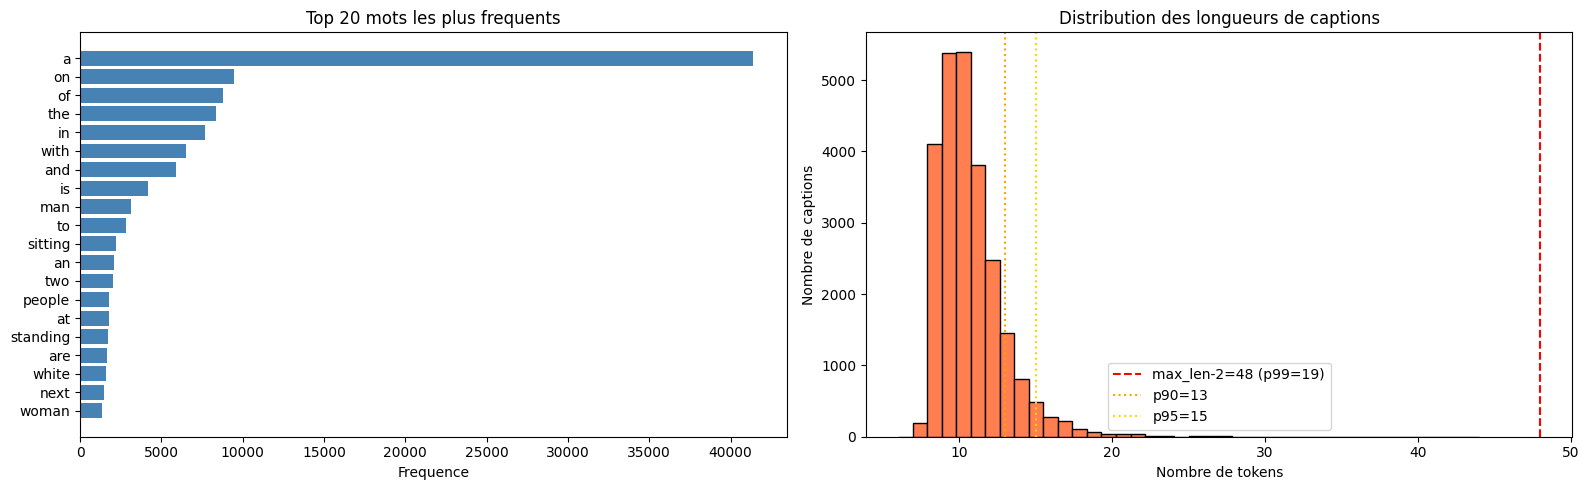


Taille du vocabulaire : 2385 tokens
Longueur min : 6 | max : 44 | moyenne : 10.5


In [6]:
# Q1 - Vocabulaire, mots frequents, distribution longueurs captions

with open('coco/annotations/captions_train2017.json') as f:
    raw_train = json.load(f)

train_img_ids_set = set(train_img_ids)
train_anns = [a for a in raw_train['annotations'] if a['image_id'] in train_img_ids_set]

caps_by_img = defaultdict(list)
for a in train_anns:
    caps_by_img[a['image_id']].append(a['caption'])

captions_list = list(caps_by_img.values())

vocab = Vocabulary(freq_threshold=5)
vocab.build(captions_list)

counter = Counter()
for caps in captions_list:
    for cap in caps:
        counter.update(Vocabulary.tokenize(cap))

top20 = counter.most_common(20)
words, freqs = zip(*top20)

all_caps_flat = [a['caption'] for a in train_anns]
lengths = [len(Vocabulary.tokenize(c)) for c in all_caps_flat]

# Percentiles pour justifier max_len 
p90, p95, p99 = np.percentile(lengths, [90, 95, 99])
print(f"Percentile 90% : {p90:.0f} tokens")
print(f"Percentile 95% : {p95:.0f} tokens")
print(f"Percentile 99% : {p99:.0f} tokens")
print(f"-> max_len=50 couvre {(np.array(lengths) <= 48).mean()*100:.1f}% des captions "
      f"(48 positions utiles = 50 - <SOS> - <EOS>)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(list(words)[::-1], list(freqs)[::-1], color='steelblue')
axes[0].set_xlabel('Frequence')
axes[0].set_title('Top 20 mots les plus frequents')

axes[1].hist(lengths, bins=40, color='coral', edgecolor='black')
axes[1].axvline(x=48, color='red', linestyle='--', label=f'max_len-2=48 (p99={p99:.0f})')
axes[1].axvline(x=p90, color='orange', linestyle=':', label=f'p90={p90:.0f}')
axes[1].axvline(x=p95, color='gold',   linestyle=':', label=f'p95={p95:.0f}')
axes[1].set_xlabel('Nombre de tokens')
axes[1].set_ylabel('Nombre de captions')
axes[1].set_title('Distribution des longueurs de captions')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTaille du vocabulaire : {len(vocab)} tokens")
print(f"Longueur min : {min(lengths)} | max : {max(lengths)} | moyenne : {np.mean(lengths):.1f}")

In [8]:
# COCOCaptionDataset - retourne aussi img_id pour le BLEU-4

class COCOCaptionDataset(Dataset):
    def __init__(self, root, ann_file, vocab, split='train',
                 img_size=224, max_len=50):
        self.root    = root
        self.vocab   = vocab
        self.max_len = max_len
        self.coco    = COCO(ann_file)

        if split == 'train':
            valid_ids = train_img_ids_set
        else:
            valid_ids = set(val_img_ids)
        self.ids = [aid for aid, ann in self.coco.anns.items()
                    if ann['image_id'] in valid_ids]

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip() if split == 'train'
                else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        ann      = self.coco.anns[self.ids[idx]]
        img_id   = ann['image_id']
        img_info = self.coco.loadImgs(img_id)[0]
        img = Image.open(
            os.path.join(self.root, img_info['file_name'])
        ).convert('RGB')
        img     = self.transform(img)
        caption = torch.tensor(
            self.vocab.numericalize(ann['caption'], self.max_len),
            dtype=torch.long
        )
        return img, caption, img_id 

loading annotations into memory...
Done (t=0.96s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Train : 25012 exemples | 782 batchs
Val   : 2502   exemples | 79 batchs


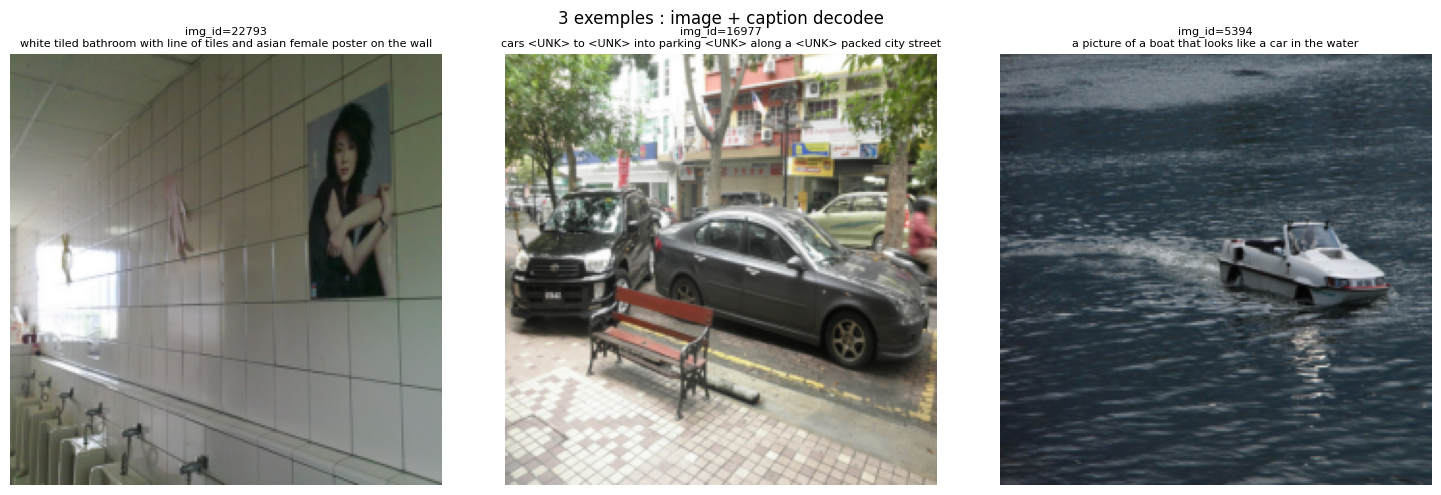

In [9]:
# Q2 - collate_fn corrigee, DataLoaders, visualisation 3 exemples

def collate_fn(batch):
    imgs, caps, img_ids = zip(*batch)          
    imgs = torch.stack(imgs, 0)
    caps = torch.stack(caps, 0)

    # Utiliser le nom explicite du token PAD
    lengths = (caps != vocab.stoi['<PAD>']).sum(dim=1).cpu()
    lengths = torch.clamp(lengths, max=caps.size(1))

    sorted_idx = torch.argsort(lengths, descending=True)
    imgs    = imgs[sorted_idx]
    caps    = caps[sorted_idx]
    lengths = lengths[sorted_idx]
    img_ids = [img_ids[i] for i in sorted_idx.tolist()]

    return imgs, caps, lengths, img_ids       


BATCH_SIZE = 32

train_dataset = COCOCaptionDataset(
    root='coco/images/train2017',
    ann_file='coco/annotations/captions_train2017.json',
    vocab=vocab, split='train', img_size=224, max_len=50
)
val_dataset = COCOCaptionDataset(
    root='coco/images/val2017',
    ann_file='coco/annotations/captions_val2017.json',
    vocab=vocab, split='val', img_size=224, max_len=50
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2,
                          pin_memory=torch.cuda.is_available())

# shuffle=False pour la reproductibilite des exemples visuels
display_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, collate_fn=collate_fn,
                            num_workers=2,
                            pin_memory=torch.cuda.is_available())

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn,
                        num_workers=2,
                        pin_memory=torch.cuda.is_available())

print(f"Train : {len(train_dataset)} exemples | {len(train_loader)} batchs")
print(f"Val   : {len(val_dataset)}   exemples | {len(val_loader)} batchs")

#  Affichage reproductible de 3 exemples 
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def decode_caption(seq, vocab):
    words = []
    for idx in seq:
        tok = vocab.itos.get(int(idx), '<UNK>')
        if tok in ('<PAD>', '<SOS>'):
            continue
        if tok == '<EOS>':
            break
        words.append(tok)
    return ' '.join(words)

def denormalize(tensor):
    img = tensor.clone().permute(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).numpy()

imgs_batch, caps_batch, lengths_batch, ids_batch = next(iter(display_loader))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(denormalize(imgs_batch[i]))
    axes[i].set_title(
        f"img_id={ids_batch[i]}\n{decode_caption(caps_batch[i], vocab)}",
        fontsize=8, wrap=True
    )
    axes[i].axis('off')
plt.suptitle('3 exemples : image + caption decodee', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Partie 2 - ImageEncoder et CaptionDecoder (fournis par le sujet)

class ImageEncoder(nn.Module):
    """Encodeur CNN base sur ResNet50 pre-entraine."""
    def __init__(self, embed_size=256, fine_tune=False):
        super().__init__()
        resnet   = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules  = list(resnet.children())[:-2]       # jusqu'a layer4 inclus
        self.resnet        = nn.Sequential(*modules)  # sortie : (B, 2048, 7, 7)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc            = nn.Linear(2048, embed_size)
        self.bn            = nn.BatchNorm1d(embed_size)

        # Geler l'encodeur sauf les 2 derniers blocs ResNet
        for param in self.resnet[:6].parameters():
            param.requires_grad = fine_tune

    def forward(self, images):
        features = self.resnet(images)                              # (B, 2048, 7, 7)
        features = self.adaptive_pool(features).squeeze(-1).squeeze(-1)  # (B, 2048)
        features = self.bn(self.fc(features))                       # (B, embed_size)
        return features


class CaptionDecoder(nn.Module):
    """Decodeur LSTM pour la generation de captions."""
    def __init__(self, embed_size, hidden_size, vocab_size,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm    = nn.LSTM(embed_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, features, captions, lengths):
        """
        features : (B, embed_size)  - vecteur image (premier token virtuel)
        captions : (B, max_len)     - sequences d'indices incluant <SOS>
        lengths  : (B,)             - longueurs reelles (avec le token image)
        """
        embeddings = self.dropout(self.embed(captions[:, :-1]))  # (B, T-1, embed)
        # Le vecteur image sert de premier token d'entree
        inputs = torch.cat([features.unsqueeze(1), embeddings], dim=1)  # (B, T, embed)

        # lengths + 1 car on a ajoute le token image en tete
        pack_lengths = torch.clamp(lengths + 1, max=inputs.size(1)).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            inputs, pack_lengths, batch_first=True, enforce_sorted=True)
        hiddens, _ = self.lstm(packed)
        hiddens, _ = nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True)
        return self.fc(hiddens)                                   # (B, T, vocab_size)

In [11]:
# Q3 - Instanciation et verification des dimensions

EMBED_SIZE  = 256
HIDDEN_SIZE = 512
NUM_LAYERS  = 2
VOCAB_SIZE  = len(vocab)

encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(device)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                         vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS,
                         dropout=0.5).to(device)

# Batch fictif
B       = 4
MAX_LEN = 50
fake_imgs = torch.randn(B, 3, 224, 224).to(device)
fake_caps = torch.randint(1, VOCAB_SIZE, (B, MAX_LEN)).to(device)
fake_lens = torch.tensor([MAX_LEN - 1, MAX_LEN - 3, MAX_LEN - 7, MAX_LEN - 10])

# Forward encoder
features = encoder(fake_imgs)
print(f"[Encoder] Input  : {tuple(fake_imgs.shape)}")
print(f"[Encoder] Output : {tuple(features.shape)}  (B, embed_size)")

# Forward decoder
outputs = decoder(features, fake_caps, fake_lens)
print(f"\n[Decoder] Captions input : {tuple(fake_caps.shape)}")
print(f"[Decoder] Lengths        : {fake_lens.tolist()}")
print(f"[Decoder] Output         : {tuple(outputs.shape)}  (B, T, vocab_size)")

# Compte des parametres
total_enc = sum(p.numel() for p in encoder.parameters())
train_enc = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
total_dec = sum(p.numel() for p in decoder.parameters())

print(f"\n[Encoder] Parametres totaux : {total_enc:,} | entrainables : {train_enc:,}")
print(f"[Decoder] Parametres totaux : {total_dec:,}")
print(f"[Total]   Entrainables      : {train_enc + total_dec:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s] 


[Encoder] Input  : (4, 3, 224, 224)
[Encoder] Output : (4, 256)  (B, embed_size)

[Decoder] Captions input : (4, 50)
[Decoder] Lengths        : [49, 47, 43, 40]
[Decoder] Output         : (4, 50, 2385)  (B, T, vocab_size)

[Encoder] Parametres totaux : 24,033,088 | entrainables : 22,588,160
[Decoder] Parametres totaux : 5,512,273
[Total]   Entrainables      : 28,100,433


Epoch 01/20 | Train Loss 4.8637 (PPL 129.5) | Val Loss 4.4868 (PPL 88.8) [SAVED]


Epoch 02/20 | Train Loss 4.4663 (PPL 87.0) | Val Loss 4.3330 (PPL 76.2) [SAVED]


Epoch 03/20 | Train Loss 4.2923 (PPL 73.1) | Val Loss 4.1259 (PPL 61.9) [SAVED]


Epoch 04/20 | Train Loss 4.0763 (PPL 58.9) | Val Loss 3.9394 (PPL 51.4) [SAVED]


Epoch 05/20 | Train Loss 3.8530 (PPL 47.1) | Val Loss 3.7800 (PPL 43.8) [SAVED]


...

Epoch 16/20 | Train Loss 2.9537 (PPL 19.2) | Val Loss 3.5065 (PPL 33.3)


Epoch 17/20 | Train Loss 2.8657 (PPL 17.6) | Val Loss 3.4919 (PPL 32.8)


Epoch 18/20 | Train Loss 2.8288 (PPL 16.9) | Val Loss 3.4901 (PPL 32.8)


Epoch 19/20 | Train Loss 2.8017 (PPL 16.5) | Val Loss 3.4990 (PPL 33.1)


Epoch 20/20 | Train Loss 2.7538 (PPL 15.7) | Val Loss 3.5034 (PPL 33.2)


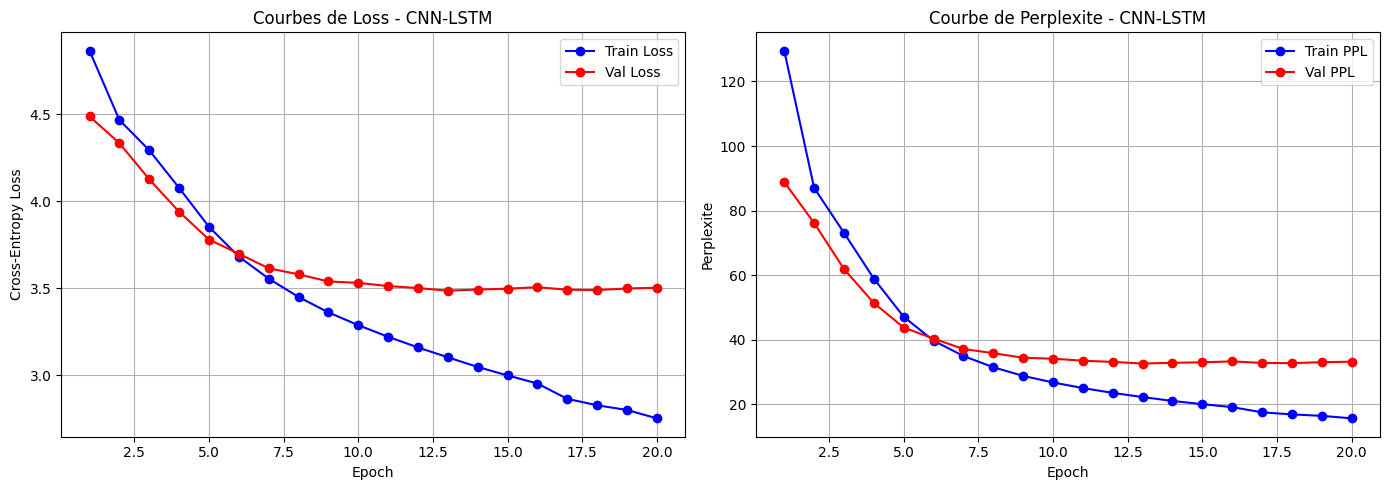


Meilleure Val Loss : 3.4864 | PPL : 32.7


In [13]:
# Q4 - Entrainement CNN-LSTM avec Teacher Forcing

def train_epoch(encoder, decoder, loader, criterion, optimizer, device):
    encoder.train(); decoder.train()
    total_loss = 0
    for imgs, caps, lengths, _ in tqdm(loader, desc='Train', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)

        features = encoder(imgs)
        outputs  = decoder(features, caps, lengths)

        targets = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))

        loss = criterion(
            outputs[:, :T].reshape(-1, outputs.size(-1)),
            targets[:, :T].reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping sur encoder ET decoder
        params = (list(filter(lambda p: p.requires_grad, encoder.parameters()))
                  + list(decoder.parameters()))
        nn.utils.clip_grad_norm_(params, max_norm=5.0)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(encoder, decoder, loader, criterion, device):
    encoder.eval(); decoder.eval()
    total_loss = 0
    for imgs, caps, lengths, _ in tqdm(loader, desc='Val', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        features = encoder(imgs)
        outputs  = decoder(features, caps, lengths)
        targets  = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, outputs.size(-1)),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()
    return total_loss / len(loader)


NUM_EPOCHS = 20
LR         = 3e-4

encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(device)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                         vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS,
                         dropout=0.5).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, encoder.parameters())) +
    list(decoder.parameters()),
    lr=LR
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)
train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss  = train_epoch(encoder, decoder, train_loader, criterion, optimizer, device)
    val_loss = eval_epoch(encoder, decoder, val_loader,   criterion, device)
    scheduler.step(val_loss)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({'encoder': encoder.state_dict(),
                    'decoder': decoder.state_dict()}, 'best_cnn_lstm.pth')
        saved_mark = " [SAVED]"
    else:
        saved_mark = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss {tr_loss:.4f} (PPL {math.exp(tr_loss):.1f}) | "
          f"Val Loss {val_loss:.4f} (PPL {math.exp(val_loss):.1f}){saved_mark}")

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs, val_losses,   'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Courbes de Loss - CNN-LSTM')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, [math.exp(l) for l in train_losses], 'b-o', label='Train PPL')
axes[1].plot(epochs, [math.exp(l) for l in val_losses],   'r-o', label='Val PPL')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexite')
axes[1].set_title('Courbe de Perplexite - CNN-LSTM')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('cnn_lstm_training.png', dpi=150)
plt.show()
print(f"\nMeilleure Val Loss : {best_val_loss:.4f} | PPL : {math.exp(best_val_loss):.1f}")

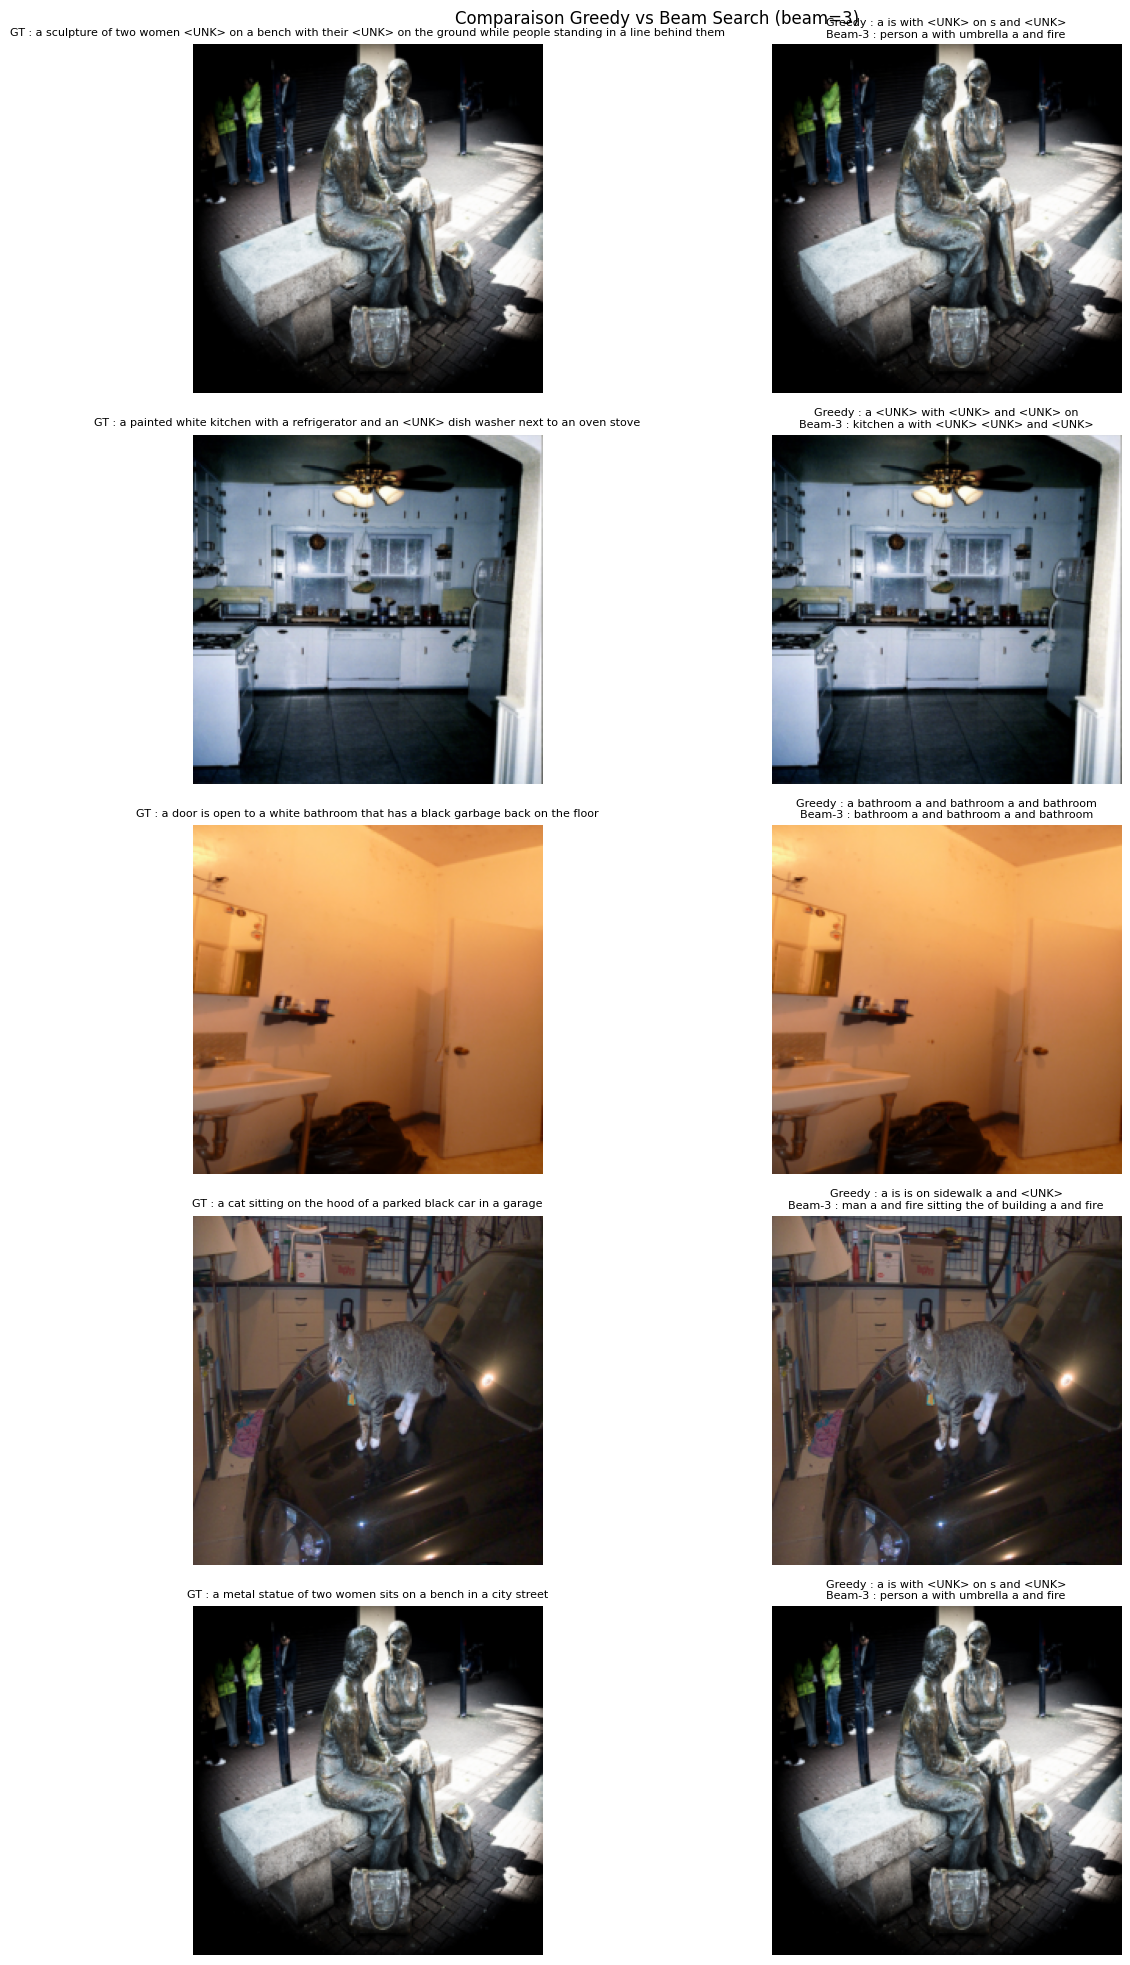


Construction du dictionnaire de references COCO (val)...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
References construites pour 500 images.
Calcul du score BLEU-4 (greedy, validation)...


BLEU-4: 100%|██████████| 79/79 [00:27<00:00,  2.86it/s]



Score BLEU-4 (greedy, validation, refs COCO) : 0.0098


In [14]:
# Q5 - Greedy, Beam Search et BLEU-4 avec vraies references COCO

import nltk
nltk.download('punkt', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

ckpt = torch.load('best_cnn_lstm.pth', map_location=device)
encoder.load_state_dict(ckpt['encoder'])
decoder.load_state_dict(ckpt['decoder'])
encoder.eval(); decoder.eval()

# Greedy search                                                        
@torch.no_grad()
def greedy_caption(encoder, decoder, image, vocab, max_len=50, device='cpu'):
    encoder.eval(); decoder.eval()
    feature = encoder(image.unsqueeze(0).to(device))
    result  = []
    inputs  = feature.unsqueeze(1)
    states  = None
    for _ in range(max_len):
        hiddens, states = decoder.lstm(inputs, states)
        output    = decoder.fc(hiddens.squeeze(1))
        predicted = output.argmax(1).item()
        tok = vocab.itos.get(predicted, '<UNK>')
        if tok in ('<EOS>', '<PAD>'):
            break
        if tok not in ('<SOS>',):
            result.append(predicted)
        inputs = decoder.embed(torch.tensor([[predicted]]).to(device))
    return ' '.join([vocab.itos.get(i, '<UNK>') for i in result])


# Beam search (fourni par le sujet, inchange)                         
@torch.no_grad()
def beam_search_caption(encoder, decoder, image, vocab, beam_size=3,
                         max_len=50, device='cpu'):
    encoder.eval(); decoder.eval()
    feature   = encoder(image.unsqueeze(0).to(device))
    beams     = [(0.0, [vocab.stoi['<SOS>']], None)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for score, seq, hidden in beams:
            last_word = torch.tensor([[seq[-1]]]).to(device)
            embed = decoder.embed(last_word)
            if hidden is None:
                inp = torch.cat([feature.unsqueeze(1), embed], dim=1)
                out, hidden = decoder.lstm(inp)
                out = out[:, -1:]
            else:
                out, hidden = decoder.lstm(embed, hidden)
            logprobs = F.log_softmax(decoder.fc(out.squeeze(1)), dim=-1)
            topk_scores, topk_ids = logprobs.topk(beam_size)
            for s, idx in zip(topk_scores[0], topk_ids[0]):
                new_seq   = seq + [idx.item()]
                new_score = score + s.item()
                if idx.item() == vocab.stoi['<EOS>']:
                    completed.append((new_score / len(new_seq), new_seq))
                else:
                    new_beams.append((new_score, new_seq,
                                      (hidden[0].clone(), hidden[1].clone())))
        beams = sorted(new_beams, key=lambda x: x[0] / len(x[1]),
                       reverse=True)[:beam_size]
        if not beams:
            break

    best = max(completed or [(0, beams[0][1])], key=lambda x: x[0])
    return ' '.join([vocab.itos.get(i, '<UNK>') for i in best[1][1:-1]])

# Comparaison qualitative sur 5 images                                
val_iter = iter(val_loader)
imgs_b, caps_b, lens_b, ids_b = next(val_iter)

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
for i in range(5):
    img_tensor = imgs_b[i]
    gt_caption = decode_caption(caps_b[i], vocab)
    greedy_cap = greedy_caption(encoder, decoder, img_tensor, vocab,
                                max_len=50, device=device)
    beam_cap   = beam_search_caption(encoder, decoder, img_tensor, vocab,
                                     beam_size=3, max_len=50, device=device)

    axes[i][0].imshow(denormalize(img_tensor))
    axes[i][0].axis('off')
    axes[i][0].set_title(f"GT : {gt_caption}", fontsize=8, wrap=True)

    axes[i][1].imshow(denormalize(img_tensor))
    axes[i][1].axis('off')
    axes[i][1].set_title(
        f"Greedy : {greedy_cap}\nBeam-3 : {beam_cap}",
        fontsize=8, wrap=True)

plt.suptitle('Comparaison Greedy vs Beam Search (beam=3)', fontsize=12)
plt.tight_layout()
plt.savefig('greedy_vs_beam.png', dpi=150)
plt.show()

# BLEU-4 avec les 5 vraies references COCO par image                  
print("\nConstruction du dictionnaire de references COCO (val)...")
val_coco = COCO('coco/annotations/captions_val2017.json')
valid_val_ids = set(val_img_ids)

# img_id -> liste de tokenisations (5 references humaines par image)
refs_by_imgid = defaultdict(list)
for aid, ann in val_coco.anns.items():
    if ann['image_id'] in valid_val_ids:
        refs_by_imgid[ann['image_id']].append(
            Vocabulary.tokenize(ann['caption']))

print(f"References construites pour {len(refs_by_imgid)} images.")
print("Calcul du score BLEU-4 (greedy, validation)...")

references = []
hypotheses = []
smooth     = SmoothingFunction().method4

with torch.no_grad():
    for imgs_v, caps_v, lens_v, img_ids_v in tqdm(val_loader, desc='BLEU-4'):
        imgs_v = imgs_v.to(device)
        for j in range(imgs_v.size(0)):
            img_id = img_ids_v[j]
            refs   = refs_by_imgid.get(img_id, None)
            if refs is None or len(refs) == 0:
                continue
            pred = greedy_caption(encoder, decoder, imgs_v[j].cpu(),
                                  vocab, max_len=50, device=device)
            hypotheses.append(Vocabulary.tokenize(pred))
            references.append(refs)          # liste des 5 references COCO

bleu4 = corpus_bleu(references, hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smooth)
print(f"\nScore BLEU-4 (greedy, validation, refs COCO) : {bleu4:.4f}")

In [15]:
# Partie 3 - BahdanauAttention et AttentionDecoder (fournis par le sujet)

class BahdanauAttention(nn.Module):
    """Attention additive sur les features spatiaux du CNN."""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att  = nn.Linear(encoder_dim, attention_dim)
        self.dec_att  = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out    : (B, num_pixels, encoder_dim)  [7x7=49 pixels]
        # decoder_hidden : (B, decoder_dim)
        att1   = self.enc_att(encoder_out)                    # (B, 49, att_dim)
        att2   = self.dec_att(decoder_hidden).unsqueeze(1)    # (B,  1, att_dim)
        energy = self.full_att(torch.tanh(att1 + att2))       # (B, 49,  1)
        alpha  = F.softmax(energy.squeeze(2), dim=1)          # (B, 49)
        context = (alpha.unsqueeze(2) * encoder_out).sum(dim=1)  # (B, enc_dim)
        return context, alpha


class AttentionDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size,
                 encoder_dim=2048, attention_dim=256, dropout=0.5):
        super().__init__()
        self.attention  = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        self.embed      = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm_cell  = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.fc         = nn.Linear(hidden_size, vocab_size)
        self.init_h     = nn.Linear(encoder_dim, hidden_size)
        self.init_c     = nn.Linear(encoder_dim, hidden_size)
        self.dropout    = nn.Dropout(dropout)

    def init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)                    # (B, encoder_dim)
        h = torch.tanh(self.init_h(mean_enc))                # (B, hidden_size)
        c = torch.tanh(self.init_c(mean_enc))                # (B, hidden_size)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        # encoder_out : (B, 49, 2048) — features spatiaux aplatis
        B     = encoder_out.size(0)
        h, c  = self.init_hidden(encoder_out)
        embeddings = self.dropout(self.embed(captions[:, :-1]))  # (B, T-1, embed)
        max_t      = embeddings.size(1)

        predictions = torch.zeros(B, max_t,
                                  self.fc.out_features).to(encoder_out.device)
        alphas      = torch.zeros(B, max_t,
                                  encoder_out.size(1)).to(encoder_out.device)

        for t in range(max_t):
            context, alpha        = self.attention(encoder_out, h)
            lstm_input            = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c                  = self.lstm_cell(lstm_input, (h, c))
            predictions[:, t]     = self.fc(self.dropout(h))
            alphas[:, t]          = alpha

        return predictions, alphas

Epoch 01/15 | Train Loss 4.1952 (PPL 66.4) | Val Loss 3.4554 (PPL 31.7) [SAVED]


Epoch 02/15 | Train Loss 3.3625 (PPL 28.9) | Val Loss 3.1177 (PPL 22.6) [SAVED]


Epoch 03/15 | Train Loss 3.0524 (PPL 21.2) | Val Loss 2.9774 (PPL 19.6) [SAVED]


Epoch 04/15 | Train Loss 2.8578 (PPL 17.4) | Val Loss 2.8947 (PPL 18.1) [SAVED]


Epoch 05/15 | Train Loss 2.7126 (PPL 15.1) | Val Loss 2.8395 (PPL 17.1) [SAVED]


...

Epoch 11/15 | Train Loss 2.1722 (PPL 8.8) | Val Loss 2.7696 (PPL 16.0)


Epoch 12/15 | Train Loss 2.0373 (PPL 7.7) | Val Loss 2.7678 (PPL 15.9)


Epoch 13/15 | Train Loss 1.9733 (PPL 7.2) | Val Loss 2.7771 (PPL 16.1)


Epoch 14/15 | Train Loss 1.9224 (PPL 6.8) | Val Loss 2.7884 (PPL 16.3)


Epoch 15/15 | Train Loss 1.8385 (PPL 6.3) | Val Loss 2.7928 (PPL 16.3)


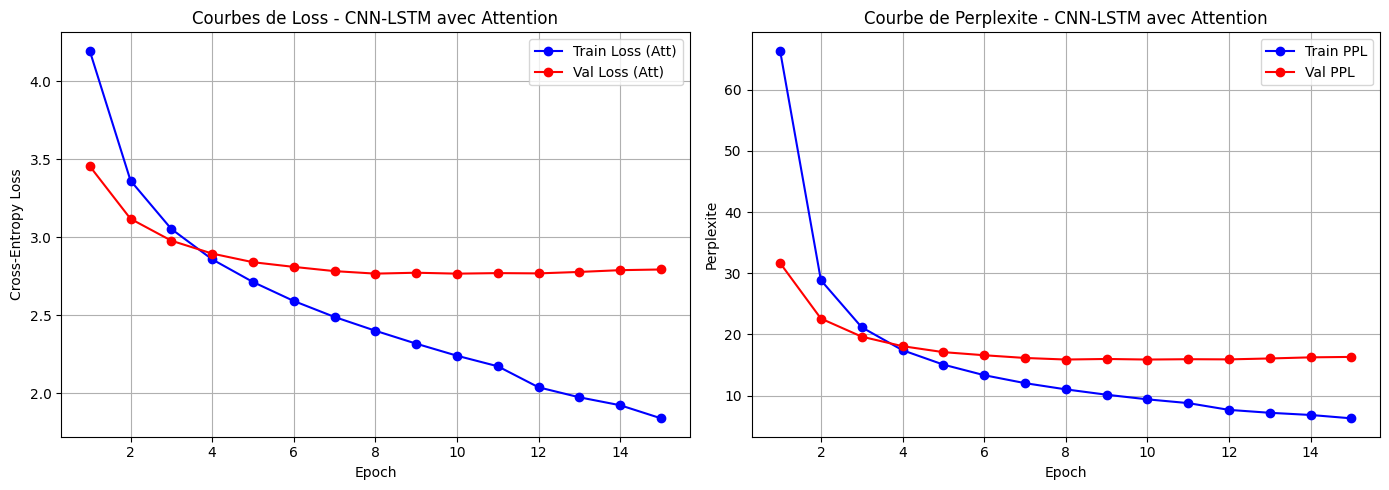


Meilleure Val Loss (Attention) : 2.7661 | PPL : 15.9

Chargement du meilleur checkpoint attention...
Calcul du BLEU-4 (modele avec attention, greedy)...


BLEU-4-Att: 100%|██████████| 79/79 [00:34<00:00,  2.28it/s]



Score BLEU-4 (avec attention, greedy) : 0.2315
Score BLEU-4 (sans attention,  greedy) : 0.0098
Gain Attention : +0.2217


In [17]:
# Q6 - Encodeur spatial, entrainement avec attention, comparaison BLEU-4

class SpatialImageEncoder(nn.Module):
    """ResNet50 modifie pour retourner (B, num_pixels, encoder_dim)."""
    def __init__(self, fine_tune=False):
        super().__init__()
        resnet   = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules  = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        for param in self.resnet[:6].parameters():
            param.requires_grad = fine_tune

    def forward(self, images):
        features = self.resnet(images)                        # (B, 2048, 7, 7)
        B, C, H, W = features.shape
        features = features.permute(0, 2, 3, 1)              # (B, 7, 7, 2048)
        features = features.reshape(B, H * W, C)             # (B, 49, 2048)
        return features


def train_epoch_att(enc, dec, loader, criterion, optimizer, device):
    enc.train(); dec.train()
    total_loss = 0
    for imgs, caps, lengths, _ in tqdm(loader, desc='Train-Att', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        enc_out             = enc(imgs)
        predictions, alphas = dec(enc_out, caps, lengths)
        targets = caps[:, 1:]
        T = min(predictions.size(1), targets.size(1))
        loss = criterion(
            predictions[:, :T].reshape(-1, predictions.size(-1)),
            targets[:, :T].reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        params = (list(filter(lambda p: p.requires_grad, enc.parameters()))
                  + list(dec.parameters()))
        nn.utils.clip_grad_norm_(params, max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch_att(enc, dec, loader, criterion, device):
    enc.eval(); dec.eval()
    total_loss = 0
    for imgs, caps, lengths, _ in tqdm(loader, desc='Val-Att', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        enc_out        = enc(imgs)
        predictions, _ = dec(enc_out, caps, lengths)
        targets = caps[:, 1:]
        T = min(predictions.size(1), targets.size(1))
        loss = criterion(
            predictions[:, :T].reshape(-1, predictions.size(-1)),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()
    return total_loss / len(loader)


ATTENTION_DIM  = 256
ENCODER_DIM    = 2048
NUM_EPOCHS_ATT = 15

enc_att = SpatialImageEncoder(fine_tune=False).to(device)
dec_att = AttentionDecoder(
    embed_size    = EMBED_SIZE,
    hidden_size   = HIDDEN_SIZE,
    vocab_size    = VOCAB_SIZE,
    encoder_dim   = ENCODER_DIM,
    attention_dim = ATTENTION_DIM,
    dropout       = 0.5
).to(device)

criterion_att = nn.CrossEntropyLoss(ignore_index=0)
optimizer_att = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, enc_att.parameters())) +
    list(dec_att.parameters()),
    lr=3e-4
)
scheduler_att = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_att, mode='min', factor=0.5, patience=2
)

train_losses_att, val_losses_att = [], []
best_val_loss_att = float('inf')

for epoch in range(1, NUM_EPOCHS_ATT + 1):
    tr_loss  = train_epoch_att(enc_att, dec_att, train_loader,
                               criterion_att, optimizer_att, device)
    val_loss = eval_epoch_att(enc_att, dec_att, val_loader,
                              criterion_att, device)
    scheduler_att.step(val_loss)
    train_losses_att.append(tr_loss)
    val_losses_att.append(val_loss)

    if val_loss < best_val_loss_att:
        best_val_loss_att = val_loss
        torch.save({'encoder': enc_att.state_dict(),
                    'decoder': dec_att.state_dict()},
                   'best_cnn_lstm_att.pth')
        saved_mark = " [SAVED]"
    else:
        saved_mark = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_ATT} | "
          f"Train Loss {tr_loss:.4f} (PPL {math.exp(tr_loss):.1f}) | "
          f"Val Loss {val_loss:.4f} (PPL {math.exp(val_loss):.1f}){saved_mark}")

epochs_att = range(1, NUM_EPOCHS_ATT + 1)
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_att, train_losses_att, 'b-o', label='Train Loss (Att)')
axes[0].plot(epochs_att, val_losses_att,   'r-o', label='Val Loss (Att)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Courbes de Loss - CNN-LSTM avec Attention')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_att, [math.exp(l) for l in train_losses_att], 'b-o', label='Train PPL')
axes[1].plot(epochs_att, [math.exp(l) for l in val_losses_att],   'r-o', label='Val PPL')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexite')
axes[1].set_title('Courbe de Perplexite - CNN-LSTM avec Attention')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('cnn_lstm_att_training.png', dpi=150)
plt.show()
print(f"\nMeilleure Val Loss (Attention) : {best_val_loss_att:.4f} | "
      f"PPL : {math.exp(best_val_loss_att):.1f}")

print("\nChargement du meilleur checkpoint attention...")
ckpt_att = torch.load('best_cnn_lstm_att.pth', map_location=device)
enc_att.load_state_dict(ckpt_att['encoder'])
dec_att.load_state_dict(ckpt_att['decoder'])
enc_att.eval(); dec_att.eval()


@torch.no_grad()
def greedy_caption_att(enc, dec, image, vocab, max_len=50, device='cpu'):
    enc.eval(); dec.eval()
    enc_out  = enc(image.unsqueeze(0).to(device))
    h, c     = dec.init_hidden(enc_out)
    word_idx = torch.tensor([vocab.stoi['<SOS>']]).to(device)
    result   = []

    for _ in range(max_len):
        embed          = dec.dropout(dec.embed(word_idx.unsqueeze(0)))
        context, _     = dec.attention(enc_out, h)
        lstm_input     = torch.cat([embed.squeeze(1), context], dim=1)
        h, c           = dec.lstm_cell(lstm_input, (h, c))
        output         = dec.fc(h)
        predicted      = output.argmax(1).item()
        tok            = vocab.itos.get(predicted, '<UNK>')
        if tok in ('<EOS>', '<PAD>'):
            break
        if tok not in ('<SOS>',):
            result.append(predicted)
        word_idx = torch.tensor([predicted]).to(device)

    return ' '.join([vocab.itos.get(i, '<UNK>') for i in result])


print("Calcul du BLEU-4 (modele avec attention, greedy)...")
refs_att, hyps_att = [], []
smooth = SmoothingFunction().method4

with torch.no_grad():
    for imgs_v, caps_v, lens_v, img_ids_v in tqdm(val_loader, desc='BLEU-4-Att'):
        imgs_v = imgs_v.to(device)
        for j in range(imgs_v.size(0)):
            img_id = img_ids_v[j]
            refs   = refs_by_imgid.get(img_id, None)
            if refs is None or len(refs) == 0:
                continue
            pred = greedy_caption_att(enc_att, dec_att, imgs_v[j].cpu(),
                                      vocab, max_len=50, device=device)
            hyps_att.append(Vocabulary.tokenize(pred))
            refs_att.append(refs)

bleu4_att = corpus_bleu(refs_att, hyps_att,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smooth)
print(f"\nScore BLEU-4 (avec attention, greedy) : {bleu4_att:.4f}")
print(f"Score BLEU-4 (sans attention,  greedy) : 0.0098")
print(f"Gain Attention : {(bleu4_att - 0.0098):+.4f}")

Visualisation des cartes d'attention pour 4 images de test :

Image 1 | GT   : a sculpture of two women <UNK> on a bench with their <UNK> on the ground while people standing in a line behind them
         | Pred : a couple of people standing next to a tree



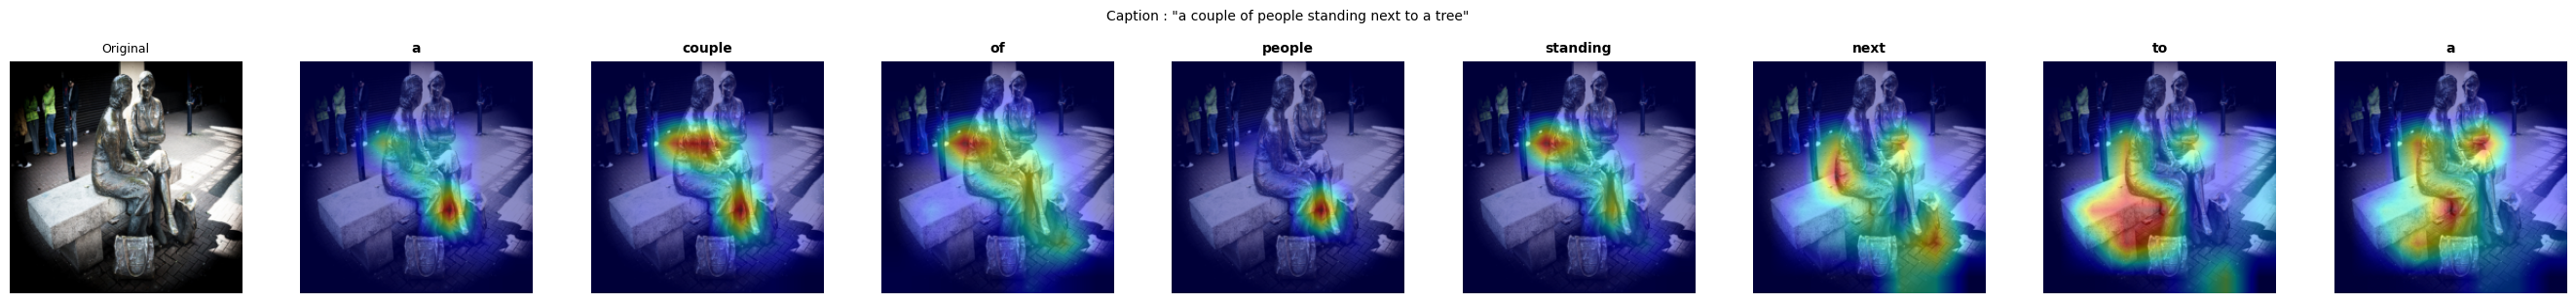

Image 2 | GT   : a painted white kitchen with a refrigerator and an <UNK> dish washer next to an oven stove
         | Pred : a kitchen with a large white stove and a stove



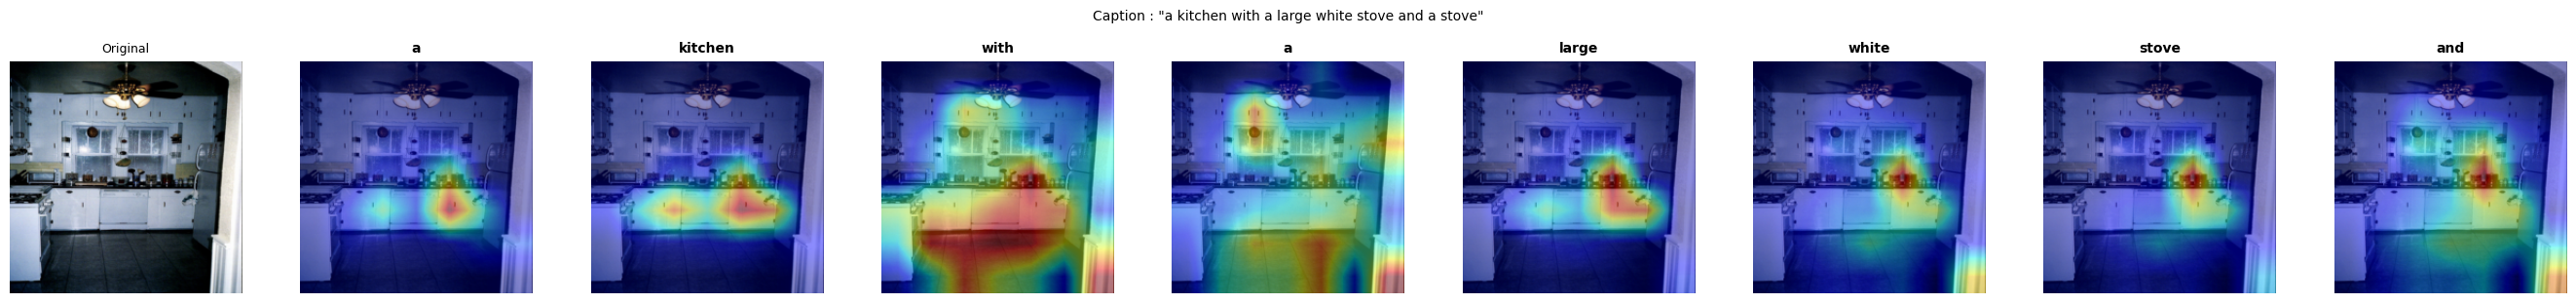

Image 3 | GT   : a door is open to a white bathroom that has a black garbage back on the floor
         | Pred : a bathroom with a small sink and a mirror



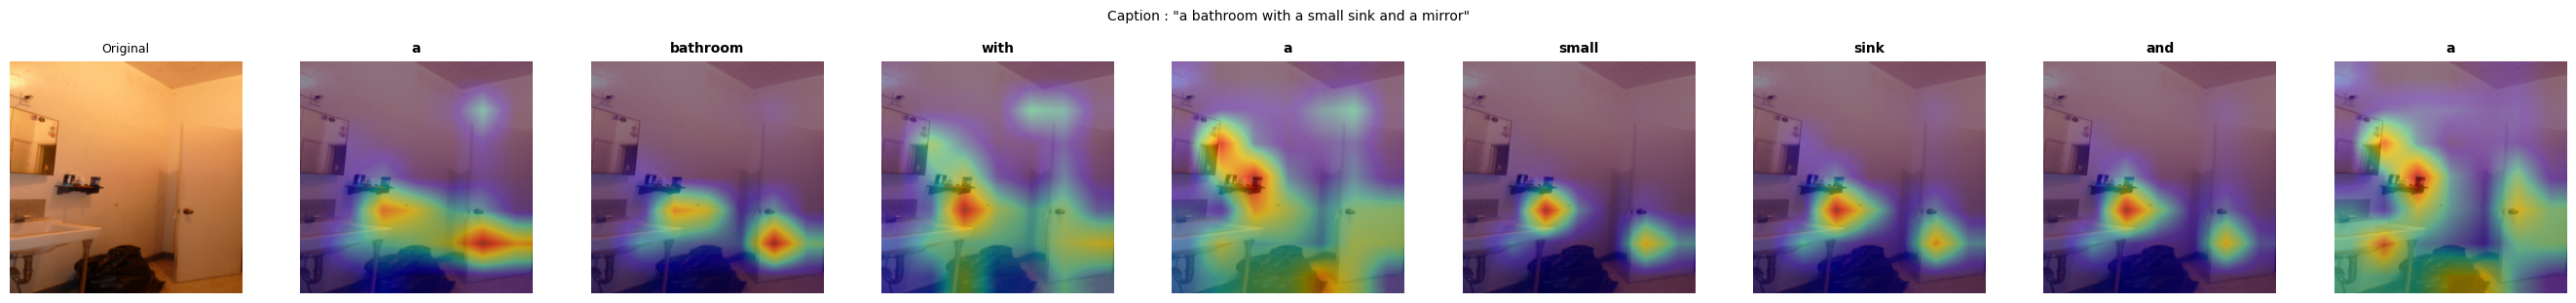

Image 4 | GT   : a cat sitting on the hood of a parked black car in a garage
         | Pred : a cat is sitting on a desk with a cat



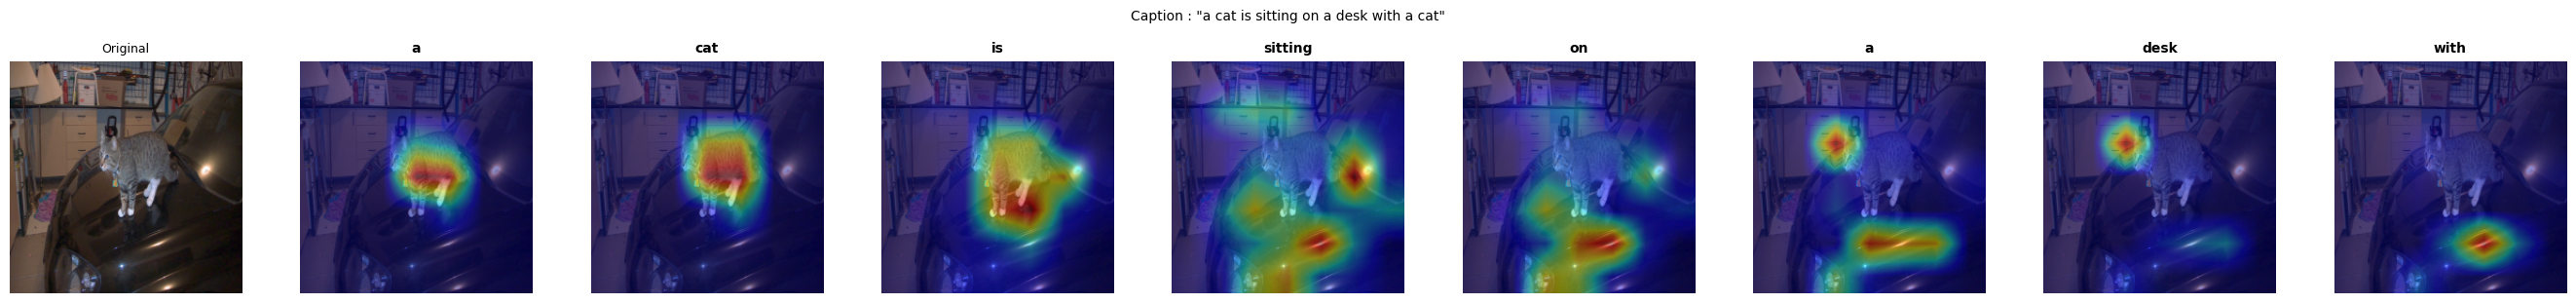

In [18]:
# Q7 - Visualisation des cartes d'attention pour 4 images de test

@torch.no_grad()
def generate_with_alphas(enc, dec, image, vocab, max_len=50, device='cpu'):
    enc.eval(); dec.eval()
    enc_out  = enc(image.unsqueeze(0).to(device))
    h, c     = dec.init_hidden(enc_out)
    word_idx = torch.tensor([vocab.stoi['<SOS>']]).to(device)
    words_out, alphas_out = [], []

    for _ in range(max_len):
        embed          = dec.dropout(dec.embed(word_idx.unsqueeze(0)))
        context, alpha = dec.attention(enc_out, h)
        lstm_input     = torch.cat([embed.squeeze(1), context], dim=1)
        h, c           = dec.lstm_cell(lstm_input, (h, c))
        output         = dec.fc(h)
        predicted      = output.argmax(1).item()
        tok            = vocab.itos.get(predicted, '<UNK>')
        if tok in ('<EOS>', '<PAD>'):
            break
        if tok not in ('<SOS>',):
            words_out.append(tok)
            alphas_out.append(alpha.squeeze(0).cpu().numpy())
        word_idx = torch.tensor([predicted]).to(device)

    return words_out, alphas_out

def show_attention_map(image_tensor, words, alphas, max_words=8):
    img_np  = denormalize(image_tensor)
    n_words = min(len(words), max_words)
    if n_words == 0:
        return
    fig, axes = plt.subplots(1, n_words + 1, figsize=(3 * (n_words + 1), 3))

    axes[0].imshow(img_np)
    axes[0].set_title('Original', fontsize=9)
    axes[0].axis('off')

    for t in range(n_words):
        alpha     = alphas[t]
        alpha_map = alpha.reshape(7, 7)
        alpha_up  = F.interpolate(
            torch.tensor(alpha_map).unsqueeze(0).unsqueeze(0).float(),
            size=(224, 224),
            mode='bilinear',
            align_corners=False
        ).squeeze().numpy()
        alpha_up = (alpha_up - alpha_up.min()) / (alpha_up.max() - alpha_up.min() + 1e-8)
        axes[t + 1].imshow(img_np)
        axes[t + 1].imshow(alpha_up, cmap='jet', alpha=0.45)
        axes[t + 1].set_title(words[t], fontsize=10, fontweight='bold')
        axes[t + 1].axis('off')

    caption_str = ' '.join(words)
    fig.suptitle(f'Caption : "{caption_str}"', fontsize=10, y=1.02)
    plt.tight_layout()

    fname = words[0] if len(words) > 0 else "empty"       # garde IndexError
    plt.savefig(f'attention_map_{fname}.png', dpi=120, bbox_inches='tight')
    plt.show()

val_iter_att = iter(val_loader)
imgs_att, caps_att, lens_att, ids_att = next(val_iter_att)

print("Visualisation des cartes d'attention pour 4 images de test :\n")
for i in range(4):
    img_tensor    = imgs_att[i]
    words, alphas = generate_with_alphas(enc_att, dec_att, img_tensor,
                                         vocab, max_len=50, device=device)
    gt = decode_caption(caps_att[i], vocab)
    print(f"Image {i+1} | GT   : {gt}")
    print(f"         | Pred : {' '.join(words)}\n")
    show_attention_map(img_tensor, words, alphas, max_words=8)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 6.4 MB/s eta 0:00:0000:01:00:01
Evaluation CNN-LSTM sans attention...


Eval-Base: 100%|██████████| 79/79 [00:27<00:00,  2.90it/s]


{'testlen': 19889, 'reflen': 21748, 'guess': [19889, 17387, 14885, 12383], 'correct': [12181, 1301, 55, 0]}
ratio: 0.914520875482761

Evaluation CNN-LSTM avec attention...


Eval-Att: 100%|██████████| 79/79 [00:35<00:00,  2.24it/s]


{'testlen': 23851, 'reflen': 23780, 'guess': [23851, 21349, 18847, 16345], 'correct': [15764, 7360, 3067, 1265]}
ratio: 1.0029857022707735

Metrique            CNN-LSTM    CNN-LSTM+Att
BLEU-1                0.5578          0.6609   (+0.1031)
BLEU-4                0.0000          0.2315   (+0.2314)
METEOR                0.1245          0.2113   (+0.0868)
CIDEr                 0.2520          0.6999   (+0.4479)


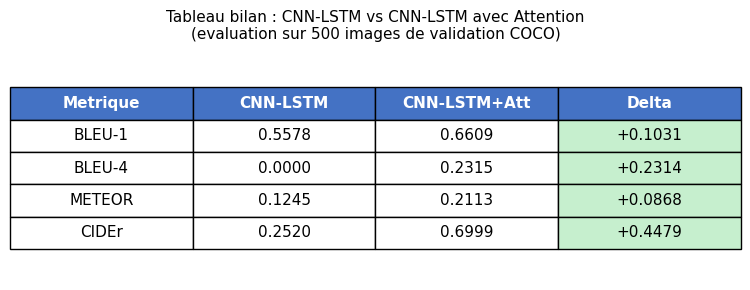

In [19]:
# Q8 - Tableau bilan comparatif des metriques automatiques

!pip install pycocoevalcap pycocotools --quiet
from pycocoevalcap.bleu.bleu     import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.cider.cider   import Cider

def build_eval_dicts(enc, dec, loader, vocab, refs_by_imgid,
                     caption_fn, device, desc='eval'):
    """
    Construit les dictionnaires gts/res au format attendu par pycocoevalcap.
    caption_fn : fonction de generation (greedy_caption ou greedy_caption_att)
    """
    gts, res = {}, {}
    uid = 0
    with torch.no_grad():
        for imgs_v, caps_v, lens_v, img_ids_v in tqdm(loader, desc=desc):
            imgs_v = imgs_v.to(device)
            for j in range(imgs_v.size(0)):
                img_id = img_ids_v[j]
                refs   = refs_by_imgid.get(img_id, None)
                if refs is None or len(refs) == 0:
                    continue
                pred = caption_fn(enc, dec, imgs_v[j].cpu(),
                                  vocab, max_len=50, device=device)
                # pycocoevalcap attend des listes de dicts {image_id, caption}
                gts[uid] = [{'image_id': uid, 'caption': ' '.join(r)} for r in refs]
                res[uid] = [{'image_id': uid, 'caption': pred}]
                uid += 1
    return gts, res

def compute_metrics(gts, res):
    """Calcule BLEU-1, BLEU-4, METEOR, CIDEr et retourne un dict."""
    scores = {}
    # BLEU
    bleu_scorer = Bleu(4)
    # pycocoevalcap attend {uid: [caption_string]}
    gts_str = {k: [d['caption'] for d in v] for k, v in gts.items()}
    res_str = {k: [d['caption'] for d in v] for k, v in res.items()}
    bleu_score, _ = bleu_scorer.compute_score(gts_str, res_str)
    scores['BLEU-1'] = bleu_score[0]
    scores['BLEU-4'] = bleu_score[3]
    # METEOR
    meteor_scorer = Meteor()
    meteor_score, _ = meteor_scorer.compute_score(gts_str, res_str)
    scores['METEOR'] = meteor_score
    # CIDEr
    cider_scorer = Cider()
    cider_score, _ = cider_scorer.compute_score(gts_str, res_str)
    scores['CIDEr'] = cider_score

    return scores


# Evaluation CNN-LSTM sans attention
print("Evaluation CNN-LSTM sans attention...")
ckpt = torch.load('best_cnn_lstm.pth', map_location=device)
encoder.load_state_dict(ckpt['encoder'])
decoder.load_state_dict(ckpt['decoder'])
gts_base, res_base = build_eval_dicts(
    encoder, decoder, val_loader, vocab, refs_by_imgid,
    greedy_caption, device, desc='Eval-Base'
)
scores_base = compute_metrics(gts_base, res_base)

#  Evaluation CNN-LSTM avec attention 
print("\nEvaluation CNN-LSTM avec attention...")
ckpt_att = torch.load('best_cnn_lstm_att.pth', map_location=device)
enc_att.load_state_dict(ckpt_att['encoder'])
dec_att.load_state_dict(ckpt_att['decoder'])

gts_att, res_att = build_eval_dicts(
    enc_att, dec_att, val_loader, vocab, refs_by_imgid,
    greedy_caption_att, device, desc='Eval-Att'
)
scores_att = compute_metrics(gts_att, res_att)

#  Tableau comparatif 
metrics = ['BLEU-1', 'BLEU-4', 'METEOR', 'CIDEr']

print("\n" + "=" * 60)
print(f"{'Metrique':<12} {'CNN-LSTM':>15} {'CNN-LSTM+Att':>15}")
print("=" * 60)
for m in metrics:
    v_base = scores_base[m]
    v_att  = scores_att[m]
    gain   = v_att - v_base
    sign   = '+' if gain >= 0 else ''
    print(f"{m:<12} {v_base:>15.4f} {v_att:>15.4f}   ({sign}{gain:.4f})")
print("=" * 60)

#  Visualisation du tableau 
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table_data = [[m,
               f"{scores_base[m]:.4f}",
               f"{scores_att[m]:.4f}",
               f"{scores_att[m] - scores_base[m]:+.4f}"]
              for m in metrics]
col_labels = ['Metrique', 'CNN-LSTM', 'CNN-LSTM+Att', 'Delta']
table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2.0)

# Colorer l'en-tete
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#4472C4')
    table[0, j].set_text_props(color='white', fontweight='bold')
# Colorer la colonne Delta selon le signe
for i, m in enumerate(metrics):
    delta = scores_att[m] - scores_base[m]
    color = '#C6EFCE' if delta >= 0 else '#FFC7CE'
    table[i + 1, 3].set_facecolor(color)

plt.title('Tableau bilan : CNN-LSTM vs CNN-LSTM avec Attention\n'
          '(evaluation sur 500 images de validation COCO)',
          fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('tableau_bilan_metriques.png', dpi=150, bbox_inches='tight')
plt.show()